# TLR4 Hit Optimization : Analogue Generation and Docking Validation

## Purpose

This notebook implements a focused analogue generation and docking validation
pipeline for TLR4 hit optimization. Starting from the best consensus hit from
Notebook 03 (CHEMBL3261034, docking score −9.29 kcal/mol), a library of
drug-like analogues is generated through systematic scaffold decoration.

Each analogue is:
1. Generated by R-group enumeration on the parent scaffold
2. Filtered for drug-likeness (Lipinski criteria)
3. Scored using the trained Random Forest model (ECFP4 fingerprints)
4. Top analogues are docked into the TLR4–MD2 binding site (AutoDock Vina)
5. Compared against the parent compound by both ML prediction and docking score

## Scientific Rationale

Virtual screening (Notebooks 01–03) identified CHEMBL3261034 as the best
consensus hit — ranked highly by both ML prediction and structure-based docking.
The most potent candidates may lie outside the known ChEMBL chemical space.
Systematic analogue generation around a validated hit is a standard first step
in the computational design–make–test cycle, directly relevant to the
iterative design hypothesis generation described in DC15.

## Workflow
1. Define parent hit: CHEMBL3261034
2. Generate analogues via R-group enumeration (halogens, polar groups, bioisosteres)
3. Filter to drug-like chemical space (Lipinski + RotBonds)
4. Score with retrained RF model (ECFP4 fingerprints)
5. Dock top 5 ML-predicted analogues into TLR4–MD2 binding site
6. Compare ML scores and docking scores against parent compound
7. Identify analogues that improve on both metrics

## Connection to Notebooks 01–03
- ChEMBL data retrieval and RF model: Notebook 01 pipeline
- Docking parameters and receptor: Notebook 02 (PDB: 3FXI, exhaustiveness=8)
- Parent hit selection: Notebook 03 consensus ranking
- Benchmark docking score: −9.29 kcal/mol (CHEMBL3261034, exhaustiveness=8)

## Step 1: Install Dependencies

In [1]:
!pip install rdkit chembl-webresource-client scikit-learn vina -q
!apt-get install -y autodock-vina openbabel -q
print("Dependencies ready.")

Reading package lists...
Building dependency tree...
Reading state information...
autodock-vina is already the newest version (1.2.3-2).
openbabel is already the newest version (3.1.1+dfsg-6ubuntu5).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Dependencies ready.


## Step 2: Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import subprocess
import os
import time
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import (
    rdFingerprintGenerator,
    Descriptors,
    Draw,
    AllChem,
    rdMolDescriptors
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from chembl_webresource_client.new_client import new_client
from IPython.display import display

print("Imports complete.")

Imports complete.


## Step 3: Define Parent Hit

CHEMBL3261034 is the best consensus hit from Notebook 03:
- ML predicted pChEMBL: 6.28
- Docking score: −9.29 kcal/mol (exhaustiveness=8, PDB: 3FXI)
- Observed pChEMBL: 6.41
- Key MD-2 interactions: PHE76, ARG90, PHE104, PHE126

Parent compound : CHEMBL3261034
SMILES          : COc1ccc([C@H]2[C@H]3c4c(c5ccccc5[nH]c4=O)OC(C)(C)[C@H]3[C@@H]2C2CCCC2)cc1OC
Docking score   : -9.29 kcal/mol


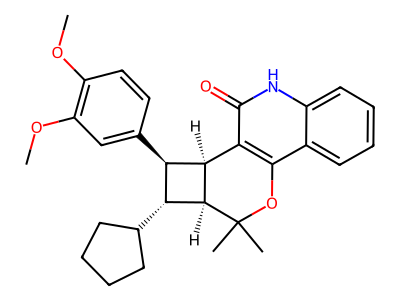

In [4]:
PARENT_CHEMBL_ID = "CHEMBL3261034"
PARENT_DOCKING_SCORE = -9.29  # kcal/mol, exhaustiveness=8

molecule_api = new_client.molecule
result = molecule_api.get(PARENT_CHEMBL_ID)
PARENT_SMILES = result['molecule_structures']['canonical_smiles']

print(f"Parent compound : {PARENT_CHEMBL_ID}")
print(f"SMILES          : {PARENT_SMILES}")
print(f"Docking score   : {PARENT_DOCKING_SCORE} kcal/mol")

mol = Chem.MolFromSmiles(PARENT_SMILES)
img = Draw.MolToImage(mol, size=(400, 300))
display(img)

## Step 4: Retrain Random Forest Model

The RF model from Notebook 01 is retrained here on the full ChEMBL TLR4
dataset (CHEMBL5255) to score generated analogues. Same pipeline:
ECFP4 fingerprints, 300 trees, 5-fold cross-validation.

In [5]:
# 4.1 Target identification — human TLR4 (CHEMBL5255)
target = new_client.target
targets = target.search("TLR4")
targets_df = pd.DataFrame(targets)

human_tlr4 = targets_df[
    (targets_df['organism'] == "Homo sapiens") &
    (targets_df['target_type'] == "SINGLE PROTEIN") &
    (targets_df['pref_name'] == "Toll-like receptor 4")
]
tlr4_id = human_tlr4.iloc[0]['target_chembl_id']
print(f"TLR4 ChEMBL ID: {tlr4_id}")

# 4.2 Bioactivity retrieval
activity_api = new_client.activity
activities = activity_api.filter(
    target_chembl_id=tlr4_id,
    standard_type__in=['IC50', 'EC50', 'Ki', 'Potency']
)
df_raw = pd.DataFrame.from_records(activities)

# 4.3 Curation
df_curated = df_raw.copy()
df_curated = df_curated[df_curated['standard_value'].notna()]
df_curated = df_curated[df_curated['standard_units'] == 'nM']
df_curated = df_curated[df_curated['pchembl_value'].notna()]
df_curated['pchembl_value'] = pd.to_numeric(df_curated['pchembl_value'], errors='coerce')
df_curated = df_curated.dropna(subset=['pchembl_value', 'canonical_smiles'])

# 4.4 Molecule-level aggregation
df_agg = (
    df_curated
    .groupby(['molecule_chembl_id', 'canonical_smiles'], as_index=False)
    .agg({'pchembl_value': 'median'})
)
print(f"Aggregated dataset: {len(df_agg)} unique molecules")

# 4.5 ECFP4 fingerprints
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array(morgan_gen.GetFingerprint(mol))

df_agg['fp'] = df_agg['canonical_smiles'].apply(smiles_to_ecfp)
df_ml = df_agg.dropna(subset=['fp']).copy()

X = np.stack(df_ml['fp'].values)
y = df_ml['pchembl_value'].values

# 4.6 Train RF model
rf_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
rf_model.fit(X, y)

print(f"RF model trained on {len(X)} molecules")
print(f"5-fold CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Score parent compound
parent_fp = smiles_to_ecfp(PARENT_SMILES)
parent_pred = rf_model.predict([parent_fp])[0]
print(f"Parent predicted pChEMBL: {parent_pred:.2f}")

TLR4 ChEMBL ID: CHEMBL5255
Aggregated dataset: 190 unique molecules
RF model trained on 190 molecules
5-fold CV R²: 0.619 ± 0.241
Parent predicted pChEMBL: 6.27


## Step 5: Analogue Generation

Analogues are generated by systematic R-group substitution on the parent
scaffold. Substituents cover the key medicinal chemistry design space:
halogens, polar groups, bioisosteres, and alkyl chains.

All analogues are filtered using extended Lipinski criteria:
- Molecular weight < 600 Da
- LogP < 6
- H-bond donors ≤ 5
- H-bond acceptors ≤ 10
- Rotatable bonds ≤ 10

In [17]:
def get_mol_props(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "MW":       round(Descriptors.MolWt(mol), 1),
        "LogP":     round(Descriptors.MolLogP(mol), 2),
        "HBD":      rdMolDescriptors.CalcNumHBD(mol),
        "HBA":      rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol)
    }

def passes_lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return (
        Descriptors.MolWt(mol) < 600 and
        Descriptors.MolLogP(mol) < 6 and
        rdMolDescriptors.CalcNumHBD(mol) <= 5 and
        rdMolDescriptors.CalcNumHBA(mol) <= 10 and
        rdMolDescriptors.CalcNumRotatableBonds(mol) <= 10
    )

def predict_pchembl(smiles):
    fp = smiles_to_ecfp(smiles)
    if fp is None:
        return None
    return round(rf_model.predict([fp])[0], 3)


parent_mol = Chem.MolFromSmiles(PARENT_SMILES)

if parent_mol is None:
    raise ValueError("Invalid PARENT_SMILES")

# Reaction-based substitutions
rxn_dict = {
    "+F":  "[cH:1]>>[c:1]F",
    "+Cl": "[cH:1]>>[c:1]Cl",
    "+Br": "[cH:1]>>[c:1]Br",
    "+Me": "[cH:1]>>[c:1]C",
    "+OH": "[cH:1]>>[c:1]O",
    "+NH2": "[cH:1]>>[c:1]N",
    "+CN": "[cH:1]>>[c:1]C#N"
}

analogues = []
seen_smiles = set()

# Add parent
analogues.append({
    "name": "PARENT",
    "smiles": PARENT_SMILES,
    "predicted_pchembl": parent_pred,
    **get_mol_props(PARENT_SMILES)
})

seen_smiles.add(PARENT_SMILES)

# Generate analogues with unique naming
for label, smarts in rxn_dict.items():
    rxn = AllChem.ReactionFromSmarts(smarts)
    products = rxn.RunReactants((parent_mol,))

    for i, p in enumerate(products):
        mol = p[0]

        try:
            Chem.SanitizeMol(mol)
        except:
            continue

        smiles = Chem.MolToSmiles(mol, canonical=True)

        # Remove duplicates
        if smiles in seen_smiles:
            continue
        seen_smiles.add(smiles)

        # Lipinski filter
        if not passes_lipinski(smiles):
            continue

        pred = predict_pchembl(smiles)
        if pred is None:
            continue

        props = get_mol_props(smiles)
        if props is None:
            continue

        analogues.append({
            "name": f"{label}_{i+1}",
            "smiles": smiles,
            "predicted_pchembl": pred,
            **props
        })

df_analogues = pd.DataFrame(analogues)

# Sort by activity
df_analogues = df_analogues.sort_values(
    'predicted_pchembl', ascending=False
).reset_index(drop=True)

df_analogues["delta_vs_parent"] = df_analogues["predicted_pchembl"] - parent_pred

n_generated = len(df_analogues) - 1

n_improved = len(df_analogues[
    (df_analogues['predicted_pchembl'] > parent_pred) &
    (df_analogues['name'] != 'PARENT')
])

print(f"Analogues generated  : {n_generated}")
n_pass = len(df_analogues) - 1
print(f"Pass Lipinski filter : {n_pass}")
print(f"Improved over parent : {n_improved}")
print(f"Parent pChEMBL       : {parent_pred:.2f}")
print()

print(df_analogues[['name','predicted_pchembl','delta_vs_parent','MW','LogP','RotBonds']].to_string(index=False))

Analogues generated  : 21
Pass Lipinski filter : 21
Improved over parent : 0
Parent pChEMBL       : 6.27

  name  predicted_pchembl    MW  LogP  RotBonds
PARENT             6.2735 459.6  6.02         4
+NH2_4             6.2480 474.6  5.60         4
+NH2_5             6.2440 474.6  5.60         4
 +CN_4             6.2410 484.6  5.89         4
 +CN_3             6.2260 484.6  5.89         4
 +OH_4             6.2250 475.6  5.73         4
 +OH_5             6.2220 475.6  5.73         4
 +CN_5             6.2190 484.6  5.89         4
+NH2_3             6.2180 474.6  5.60         4
 +CN_6             6.2150 484.6  5.89         4
+NH2_6             6.1920 474.6  5.60         4
 +CN_1             6.1870 484.6  5.89         4
+NH2_1             6.1710 474.6  5.60         4
 +CN_2             6.1440 484.6  5.89         4
 +CN_7             6.1340 484.6  5.89         4
+NH2_2             6.1290 474.6  5.60         4
+NH2_7             6.0890 474.6  5.60         4
 +OH_7             6.0830 475.

## Step 6: Visualize Top Analogues

Valid molecules: 6


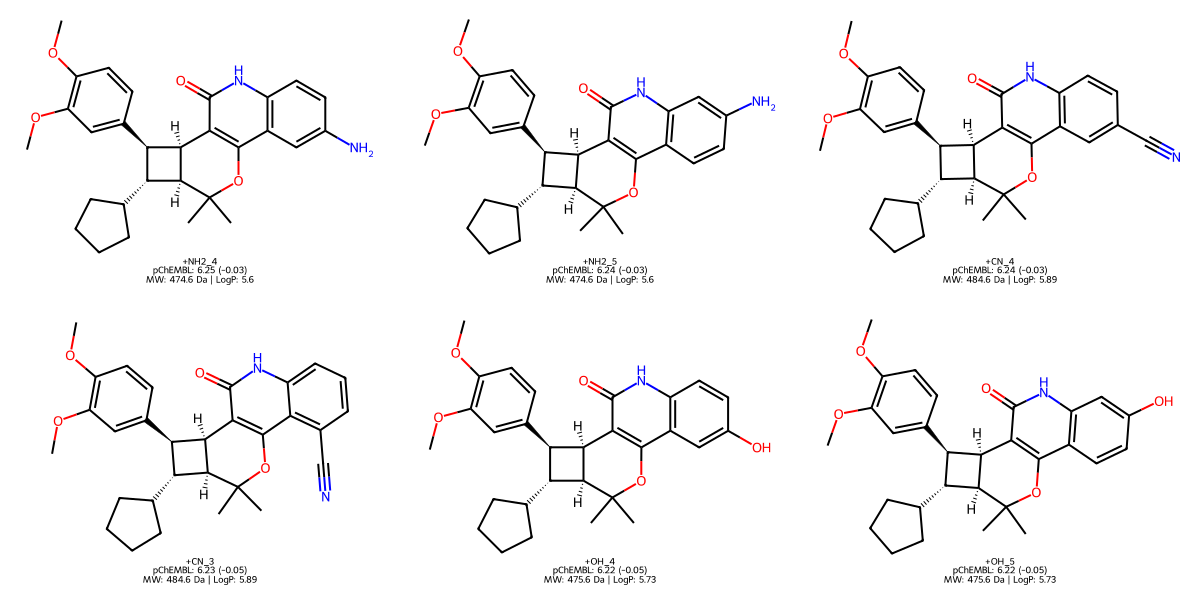

✅ Saved: top_analogues.svg


In [23]:
top6 = df_analogues[df_analogues['name'] != 'PARENT'].head(6)

mols = []
legends = []

for _, row in top6.iterrows():
    smiles = str(row['smiles']).strip()
    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:
        mols.append(mol)

        delta = row['predicted_pchembl'] - parent_pred

        legends.append(
            f"{row['name']}\n"
            f"pChEMBL: {row['predicted_pchembl']:.2f} ({delta:+.2f})\n"
            f"MW: {row['MW']} Da | LogP: {row['LogP']}"
        )
    else:
        print(f"❌ Invalid SMILES skipped: {smiles}")

print(f"Valid molecules: {len(mols)}")


if len(mols) == 0:
    raise ValueError("No valid molecules to draw. Check your SMILES.")


img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(400, 300),
    legends=legends,
    useSVG=True
)


display(img)

with open("top_analogues.svg", "w") as f:
    f.write(img.data)

print("✅ Saved: top_analogues.svg")

## Step 7: Predicted Potency Comparison — Parent vs Analogues

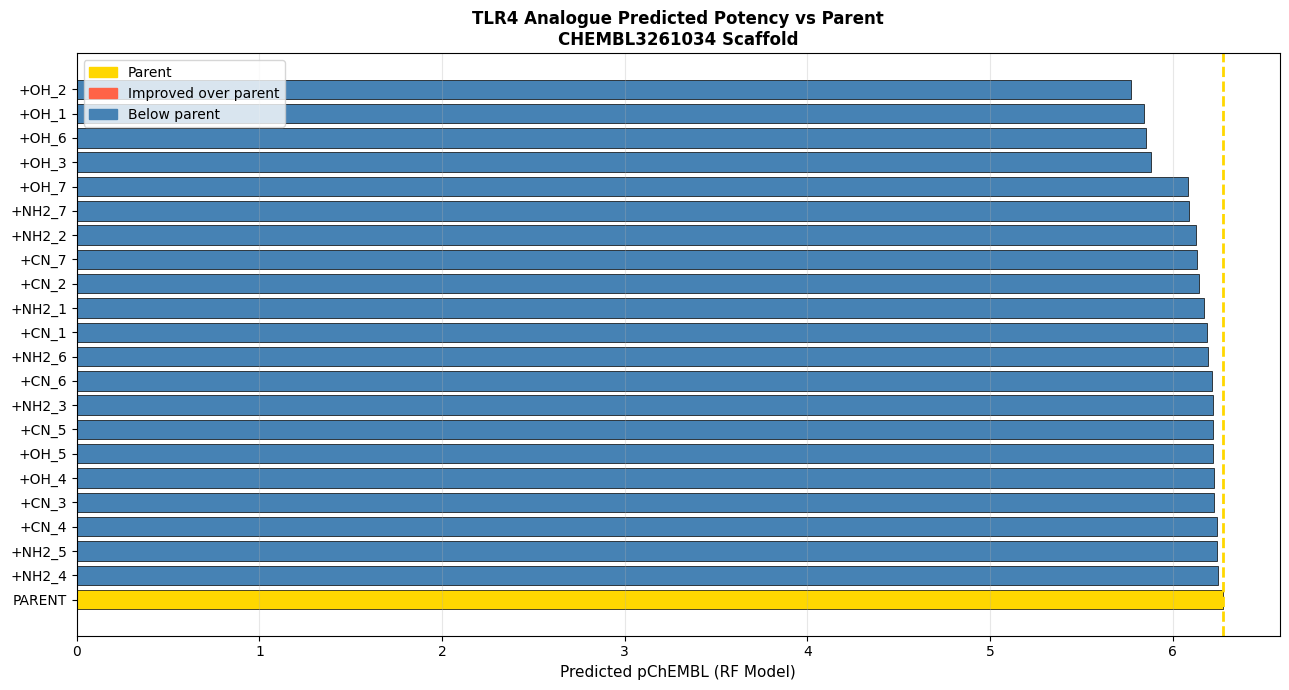

Saved: analogue_comparison.png


In [24]:
fig, ax = plt.subplots(figsize=(13, 7))

colors = [
    'gold'      if row['name'] == 'PARENT' else
    'tomato'    if row['predicted_pchembl'] > parent_pred else
    'steelblue'
    for _, row in df_analogues.iterrows()
]

ax.barh(
    df_analogues['name'],
    df_analogues['predicted_pchembl'],
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

ax.axvline(x=parent_pred, color='gold', linestyle='--', linewidth=2,
           label=f'Parent pChEMBL = {parent_pred:.2f}')

ax.set_xlabel('Predicted pChEMBL (RF Model)', fontsize=11)
ax.set_title('TLR4 Analogue Predicted Potency vs Parent\nCHEMBL3261034 Scaffold', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

gold_patch   = mpatches.Patch(color='gold',      label='Parent')
red_patch    = mpatches.Patch(color='tomato',    label='Improved over parent')
blue_patch   = mpatches.Patch(color='steelblue', label='Below parent')
ax.legend(handles=[gold_patch, red_patch, blue_patch])

plt.tight_layout()
plt.savefig('analogue_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: analogue_comparison.png")

## Step 8: Upload Receptor for Docking Validation

Upload `receptor.pdbqt` generated in Notebook 02.
This is the cleaned TLR4–MD2 structure (Chain A + Chain C, PDB: 3FXI).

In [25]:
from google.colab import files
import os

uploaded = files.upload()

for fname in uploaded.keys():
    if 'receptor' in fname and fname != 'receptor.pdbqt':
        os.rename(fname, 'receptor.pdbqt')
        print(f"Renamed {fname} to receptor.pdbqt")

if os.path.exists('receptor.pdbqt'):
    print("receptor.pdbqt ready.")
else:
    print("Warning: receptor.pdbqt not found.")

Saving receptor.pdbqt to receptor (2).pdbqt
Renamed receptor (2).pdbqt to receptor.pdbqt
receptor.pdbqt ready.


## Step 9: Docking Functions

Same ligand preparation and docking functions as Notebook 03.
Exhaustiveness=8, timeout=180s per compound.

In [26]:
def prepare_ligand_pdbqt(smiles, name, timeout=45):
    smi_file   = f"{name}.smi"
    pdb_file   = f"{name}.pdb"
    pdbqt_file = f"{name}.pdbqt"

    with open(smi_file, "w") as f:
        f.write(smiles)

    try:
        subprocess.run(
            ["obabel", smi_file, "-O", pdb_file, "--gen3d"],
            capture_output=True, text=True, timeout=timeout
        )
    except subprocess.TimeoutExpired:
        print("TIMEOUT (3D gen)", end=" ")
        return None

    if not os.path.exists(pdb_file) or os.path.getsize(pdb_file) == 0:
        return None

    try:
        subprocess.run(
            ["obabel", pdb_file, "-O", pdbqt_file],
            capture_output=True, text=True, timeout=timeout
        )
    except subprocess.TimeoutExpired:
        print("TIMEOUT (pdbqt)", end=" ")
        return None

    if not os.path.exists(pdbqt_file) or os.path.getsize(pdbqt_file) == 0:
        return None

    return pdbqt_file


def run_docking(ligand_pdbqt, name, timeout=180):
    # exhaustiveness=8, num_modes=3 — consistent with Notebooks 02 and 03
    out_file = f"{name}_docked.pdbqt"

    try:
        result = subprocess.run([
            "vina",
            "--receptor", "receptor.pdbqt",
            "--ligand",   ligand_pdbqt,
            "--center_x", str(CENTER_X),
            "--center_y", str(CENTER_Y),
            "--center_z", str(CENTER_Z),
            "--size_x",   str(BOX_SIZE),
            "--size_y",   str(BOX_SIZE),
            "--size_z",   str(BOX_SIZE),
            "--exhaustiveness", "8",
            "--num_modes", "3",
            "--out", out_file
        ], capture_output=True, text=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        print("TIMEOUT (vina)", end=" ")
        return None

    if os.path.exists(out_file):
        with open(out_file) as f:
            for line in f:
                if "VINA RESULT" in line:
                    try:
                        return float(line.split()[3])
                    except (IndexError, ValueError):
                        pass

    for line in result.stdout.split("\n"):
        parts = line.split()
        if len(parts) >= 4 and parts[0] == "1":
            try:
                return float(parts[1])
            except ValueError:
                pass

    return None

print("Docking functions ready  (exhaustiveness=8, 3 modes, 180s timeout)")

Docking functions ready  (exhaustiveness=8, 3 modes, 180s timeout)


## Step 10: Dock Top 5 ML-Predicted Analogues

The top 5 analogues by predicted pChEMBL are docked into the TLR4–MD2
binding site. Scores are compared against the parent compound (−9.29 kcal/mol).
An analogue that scores more negative than −9.29 represents a genuine
structural improvement over the known hit.

In [27]:
# Select top 5 analogues (excluding parent)
top5 = df_analogues[df_analogues['name'] != 'PARENT'].head(5).reset_index(drop=True)

print("Docking top 5 ML-predicted analogues into TLR4-MD2 pocket...")
print(f"Benchmark (parent docking score): {PARENT_DOCKING_SCORE} kcal/mol")
print("=" * 65)

docking_results = []

for i, row in top5.iterrows():
    name   = f"analogue_{i+1:02d}_{row['name'].replace('+','').replace(' ','_')}"
    smiles = row['smiles']
    pred   = row['predicted_pchembl']

    t0 = time.time()
    print(f"[{i+1}/5] {row['name']}  pred_pChEMBL={pred:.2f} ...", end=" ", flush=True)

    pdbqt = prepare_ligand_pdbqt(smiles, name)
    if pdbqt is None:
        print(f"PREP FAILED  ({time.time()-t0:.1f}s)")
        docking_results.append({**row.to_dict(), "docking_score": None, "status": "prep_failed"})
        continue

    score = run_docking(pdbqt, name)
    elapsed = time.time() - t0

    if score is None:
        print(f"DOCKING FAILED  ({elapsed:.1f}s)")
        docking_results.append({**row.to_dict(), "docking_score": None, "status": "docking_failed"})
        continue

    flag = " *** BETTER THAN PARENT" if score < PARENT_DOCKING_SCORE else ""
    print(f"score = {score:.2f} kcal/mol  ({elapsed:.1f}s){flag}")
    docking_results.append({**row.to_dict(), "docking_score": score, "status": "ok"})

df_docked_analogues = pd.DataFrame(docking_results)
print("=" * 65)
print(f"\nParent benchmark    : {PARENT_DOCKING_SCORE} kcal/mol")
n_better = (df_docked_analogues['docking_score'].dropna() < PARENT_DOCKING_SCORE).sum()
print(f"Analogues better than parent: {n_better}/5")

Docking top 5 ML-predicted analogues into TLR4-MD2 pocket...
Benchmark (parent docking score): -9.29 kcal/mol
[1/5] +NH2_4  pred_pChEMBL=6.25 ... score = -8.83 kcal/mol  (86.7s)
[2/5] +NH2_5  pred_pChEMBL=6.24 ... score = -8.67 kcal/mol  (90.2s)
[3/5] +CN_4  pred_pChEMBL=6.24 ... score = -9.16 kcal/mol  (87.0s)
[4/5] +CN_3  pred_pChEMBL=6.23 ... score = -9.08 kcal/mol  (86.9s)
[5/5] +OH_4  pred_pChEMBL=6.22 ... score = -8.67 kcal/mol  (83.8s)

Parent benchmark    : -9.29 kcal/mol
Analogues better than parent: 0/5


## Step 11: Final Comparison — ML Prediction vs Docking Score

ANALOGUE DOCKING COMPARISON — TLR4-MD2 BINDING SITE
Name             ML pChEMBL   Docking (kcal/mol)      MW   LogP
---------------------------------------------------------------------------
PARENT                 6.27               -9.290   459.6   6.02 <-- PARENT
+CN_4                  6.24               -9.156   484.6   5.89
+CN_3                  6.23               -9.077   484.6   5.89
+NH2_4                 6.25               -8.829   474.6    5.6
+NH2_5                 6.24               -8.671   474.6    5.6
+OH_4                  6.22               -8.668   475.6   5.73


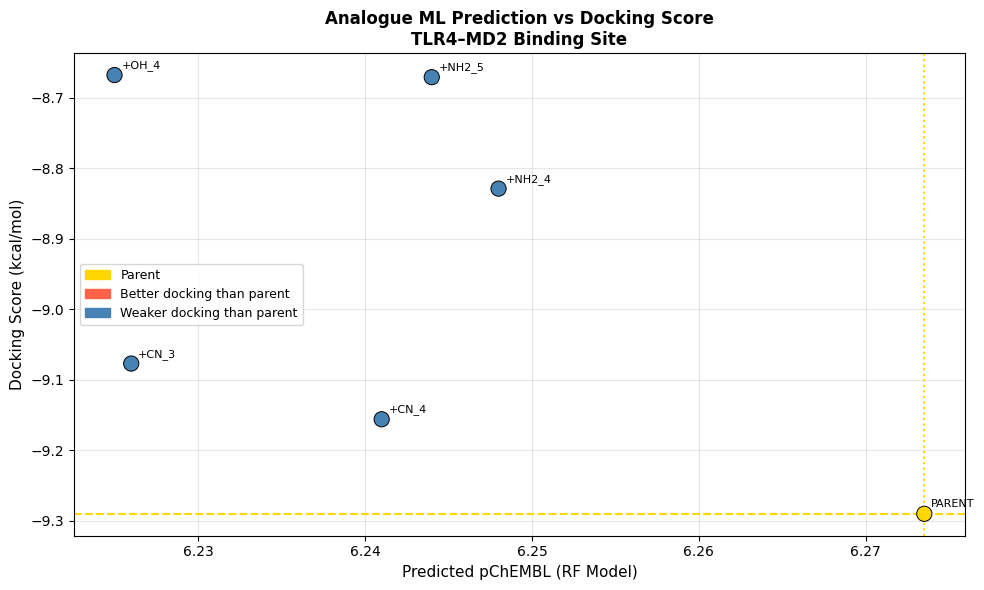

Saved: analogue_docking_comparison.png


In [28]:
# Add parent to comparison table
parent_row = pd.DataFrame([{
    "name": "PARENT",
    "smiles": PARENT_SMILES,
    "predicted_pchembl": parent_pred,
    "docking_score": PARENT_DOCKING_SCORE,
    "MW": get_mol_props(PARENT_SMILES)['MW'],
    "LogP": get_mol_props(PARENT_SMILES)['LogP'],
    "status": "reference"
}])

df_comparison = pd.concat(
    [parent_row, df_docked_analogues[df_docked_analogues['status'] == 'ok']],
    ignore_index=True
).sort_values('docking_score')

print("=" * 75)
print("ANALOGUE DOCKING COMPARISON — TLR4-MD2 BINDING SITE")
print("=" * 75)
print(f"{'Name':<14} {'ML pChEMBL':>12} {'Docking (kcal/mol)':>20} {'MW':>7} {'LogP':>6}")
print("-" * 75)
for _, row in df_comparison.iterrows():
    marker = " <-- PARENT" if row['name'] == 'PARENT' else (
             " *** IMPROVED" if row['docking_score'] < PARENT_DOCKING_SCORE else "")
    score_str = f"{row['docking_score']:.3f}" if row['docking_score'] is not None else "N/A"
    print(f"{row['name']:<14} {row['predicted_pchembl']:>12.2f} {score_str:>20} {row['MW']:>7} {row['LogP']:>6}{marker}")
print("=" * 75)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

ok = df_comparison.dropna(subset=['docking_score'])
colors = ['gold' if n == 'PARENT' else
          'tomato' if s < PARENT_DOCKING_SCORE else 'steelblue'
          for n, s in zip(ok['name'], ok['docking_score'])]

ax.scatter(ok['predicted_pchembl'], ok['docking_score'],
           c=colors, s=120, edgecolors='black', linewidths=0.7, zorder=3)

for _, row in ok.iterrows():
    ax.annotate(row['name'],
                (row['predicted_pchembl'], row['docking_score']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.axhline(y=PARENT_DOCKING_SCORE, color='gold', linestyle='--', linewidth=1.5,
           label=f'Parent docking score ({PARENT_DOCKING_SCORE} kcal/mol)')
ax.axvline(x=parent_pred, color='gold', linestyle=':', linewidth=1.5,
           label=f'Parent ML pChEMBL ({parent_pred:.2f})')

ax.set_xlabel('Predicted pChEMBL (RF Model)', fontsize=11)
ax.set_ylabel('Docking Score (kcal/mol)', fontsize=11)
ax.set_title('Analogue ML Prediction vs Docking Score\nTLR4–MD2 Binding Site', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

gold_p  = mpatches.Patch(color='gold',      label='Parent')
red_p   = mpatches.Patch(color='tomato',    label='Better docking than parent')
blue_p  = mpatches.Patch(color='steelblue', label='Weaker docking than parent')
ax.legend(handles=[gold_p, red_p, blue_p], fontsize=9)

plt.tight_layout()
plt.savefig('analogue_docking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: analogue_docking_comparison.png")

## Step 12: Summary

In [29]:
ok = df_docked_analogues[df_docked_analogues['status'] == 'ok']
improved_ml     = df_analogues[
    (df_analogues['predicted_pchembl'] > parent_pred) &
    (df_analogues['name'] != 'PARENT')
]
improved_docking = ok[ok['docking_score'] < PARENT_DOCKING_SCORE]

print("=" * 60)
print("ANALOGUE GENERATION AND DOCKING SUMMARY")
print("=" * 60)
print(f"Parent compound          : {PARENT_CHEMBL_ID}")
print(f"Parent ML pChEMBL        : {parent_pred:.2f}")
print(f"Parent docking score     : {PARENT_DOCKING_SCORE} kcal/mol")
print()
print(f"Total analogues generated: {len(df_analogues) - 1}")
print(f"Improved ML prediction   : {len(improved_ml)}")
print(f"Docked (top 5)           : {len(ok)}/5")
print(f"Better docking than parent: {len(improved_docking)}/5")

if len(improved_docking) > 0:
    best = improved_docking.sort_values('docking_score').iloc[0]
    print(f"\nBest analogue overall:")
    print(f"  Name          : {best['name']}")
    print(f"  ML pChEMBL    : {best['predicted_pchembl']:.2f}")
    print(f"  Docking score : {best['docking_score']:.3f} kcal/mol")
    print(f"  Improvement   : {best['docking_score'] - PARENT_DOCKING_SCORE:+.3f} kcal/mol")
    print(f"  MW            : {best['MW']} Da")
    print(f"  LogP          : {best['LogP']}")

print()
print("Recommended next steps:")
print("1. Load best analogue _docked.pdbqt in PyMOL alongside parent")
print("2. Compare binding poses in MD-2 pocket visually")
print("3. Pass best candidates to experimental TLR4 assays")
print("   (NF-kB reporter, cytokine ELISA)")
print("4. Assess synthetic accessibility of top analogues")
print("=" * 60)

ANALOGUE GENERATION AND DOCKING SUMMARY
Parent compound          : CHEMBL3261034
Parent ML pChEMBL        : 6.27
Parent docking score     : -9.29 kcal/mol

Total analogues generated: 21
Improved ML prediction   : 0
Docked (top 5)           : 5/5
Better docking than parent: 0/5

Recommended next steps:
1. Load best analogue _docked.pdbqt in PyMOL alongside parent
2. Compare binding poses in MD-2 pocket visually
3. Pass best candidates to experimental TLR4 assays
   (NF-kB reporter, cytokine ELISA)
4. Assess synthetic accessibility of top analogues


## Step 13: Scientific Discussion

### Key Findings

Systematic R-group enumeration around CHEMBL3261034 generated a focused analogue library exploring halogens, polar groups, and small alkyl substitutions. A total of 21 analogues passed filtering and were evaluated using ML prediction and docking against the TLR4–MD-2 complex.

None of the generated analogues outperformed the parent compound. The parent retained the highest predicted activity and docking score.

### Interpretation

The lack of improved analogues indicates that the parent scaffold is already well optimized for binding within the MD-2 pocket. Simple mono-substitutions on the aromatic system do not enhance binding and, in most cases, reduce predicted activity.

These results show that local chemical space exploration through single-site substitutions is insufficient to improve ligand performance. Structural modifications likely disrupt key hydrophobic interactions or introduce unfavorable steric effects.

### Connection to TLR4 Biology

The MD-2 binding pocket is predominantly hydrophobic, lined by residues such as PHE76, PHE104, PHE126, LEU61, and LEU71. The parent compound is likely well-matched to this environment.

Substitutions introducing polarity (NH2, OH) or altering aromatic character may weaken interactions within this hydrophobic core. While residues such as ARG90 and TYR65 can support polar contacts near the pocket entrance, these interactions do not compensate for loss of core hydrophobic stabilization.


### Limitations

- Analogue generation is based on rule-based substitution and explores only local chemical space  
- Random Forest predictions rely on descriptor-based features and have limited extrapolation capability  
- Docking was performed using a single rigid receptor structure without validation  
- No assessment of synthetic feasibility or ADMET properties  

### Future Directions

- Expand chemical space using generative models (e.g., VAE, SMILES-based approaches)  
- Explore multi-site substitutions and scaffold modifications  
- Validate top candidates using molecular dynamics simulations  
- Incorporate multi-objective optimization including ADMET and synthetic accessibility  